#Arquivo de Suporte para Plotar Gráficos das redes MLP, FastKAN e KKAN: LunarLander

Autor: Renato França de Almeida - PPGEEC EMC/UFG

#1. Importação

In [ ]:
import re
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Configurações
ARQUIVOS = {
    "MLP": "mlp_rewards.csv",
    "FastKAN": "fastkan_rewards.csv",
    "KKAN": "kkan_rewards.csv"
}
ARQUIVOS_TEMPO = {
    "MLP": "mlp_tempos.csv",
    "FastKAN": "fastkan_tempos.csv",
    "KKAN": "kkan_tempos.csv"
}

JANELA = 100
LIMITE_SUCESSO = 200

PASTA_SAIDA = Path("graficos")
PASTA_SAIDA.mkdir(exist_ok=True)

PASTA_RECOMPENSA = Path("recompensas")
PASTA_RECOMPENSA.mkdir(exist_ok=True)

#2. Suporte

##Extração e cáluclos

In [ ]:
def extrair_rewards(arquivo_entrada, arquivo_saida, arquivo_tempos, seeds):
  """
  EXTRAÇÃO: le um arquivo TXT contendo as saídas de várias execuções
  e gera um CSV contendo seed | episode | reward
  Cada bloco de execução deve conter a identificação da seed.
  """
  texto = Path(arquivo_entrada).read_text(encoding="utf-8")
  linhas_resultado = []
  tempos_resultado = []
  seed_atual = None

  # Percorre linha por linha da saída do prompt da rede
  for linha in texto.splitlines():
    # Detecta a seed
    match_seed = re.search(
        r'\bseed\s*[:=]?\s*(\d+)\b',
        linha,
        re.IGNORECASE
    )
    if match_seed:
      seed_detectada = int(match_seed.group(1))
      if seed_detectada in seeds:
        seed_atual = seed_detectada
        print(f"Seed detectada: {seed_atual}")
      continue

    # Detecta linha de episódio
    match_episode = re.search(
        r'Ep\s+(\d+)\s*/\s*\d+.*?\|\s*R:\s*([-+]?\d+(?:\.\d+)?)',
        linha,
        re.IGNORECASE
    )
    if match_episode and seed_atual is not None:
      episodio = int(match_episode.group(1))
      recompensa = float(match_episode.group(2))
      linhas_resultado.append({
          "seed": seed_atual,
          "episode": episodio,
          "reward": recompensa
      })
    # Detecta tempo de treinamento
    match_tempo = re.search(
        r'Finalizou\s+a\s+execução\s+em\s+([\d.]+)\s+segundos',
        linha,
        re.IGNORECASE
    )

    if match_tempo and seed_atual is not None:
      tempo = float(match_tempo.group(1))
      tempos_resultado.append({
          "seed": seed_atual,
          "tempo_segundos": tempo
      })
      print(
          f"  Seed {seed_atual}: "
          f"{tempo:.2f} segundos"
      )

  # Verificação
  if not linhas_resultado:
    raise ValueError(
        "Nenhuma recompensa foi encontrada. "
        "Verifique o formato do arquivo TXT."
    )

  # Ordenação
  linhas_resultado.sort(
      key=lambda x: (x["seed"], x["episode"])
  )

  # Grava CSV de recompensas
  with open(
      arquivo_saida,
      "w",
      newline="",
      encoding="utf-8"
  ) as arquivo:
    writer = csv.DictWriter(
        arquivo,
        fieldnames=["seed", "episode", "reward"]
    )
    writer.writeheader()
    writer.writerows(linhas_resultado)

  # Grava CSV de tempos
  with open(
      arquivo_tempos,
      "w",
      newline="",
      encoding="utf-8"
  ) as arquivo:
    writer = csv.DictWriter(
        arquivo,
        fieldnames=[
            "seed",
            "tempo_segundos"
        ]
    )
    writer.writeheader()
    writer.writerows(tempos_resultado)

  # Estatísticas da extração
  print("\nExtração concluída!")
  print(f"Arquivo de recompensas: {arquivo_saida}")
  print(f"Arquivo de tempos: {arquivo_tempos}")
  print(f"Total de registros: {len(linhas_resultado)}")
  print("\nRegistros por seed:")
  for seed in seeds:
    registros = [
        x for x in linhas_resultado
        if x["seed"] == seed
    ]
    if registros:
      episodios = [
          x["episode"]
          for x in registros
      ]
      print(
          f"Seed {seed}: "
          f"{len(registros)} episódios "
          f"({min(episodios)} até {max(episodios)})"
      )
    else:
        print(
            f"Seed {seed}: "
            f"NENHUM registro encontrado"
        )


def carregar_dados(caminho):
  """
  Leitura CSV
  """
  df = pd.read_csv(caminho)
  # Garantia dos tipos
  df["seed"] = df["seed"].astype(int)
  df["episode"] = df["episode"].astype(int)
  df["reward"] = df["reward"].astype(float)
  return df


def calcular_estatisticas_por_episodio(df):
  """
  Média das 5 seeds ± desvio-padrão
  """
  estatisticas = (
      df
      .groupby("episode")["reward"]
      .agg(
          mean="mean",
          std="std",
          min="min",
          max="max",
          count="count"
      )
      .reset_index()
  )
  # Caso exista apenas uma seed em algum episódio
  estatisticas["std"] = (
      estatisticas["std"]
      .fillna(0)
  )
  # Média móvel da média das seeds
  estatisticas["moving_mean"] = (
      estatisticas["mean"]
      .rolling(
          window=JANELA,
          min_periods=1
      )
      .mean()
  )
  return estatisticas


def calcular_metricas_finais(df, modelo):
  """
  Calcula as métricas finais de cada seed e o resumo
  estatístico da arquitetura.
  """
  resultados = []

  for seed, grupo in df.groupby("seed"):
    grupo = grupo.sort_values("episode")
    ultimos = grupo.tail(JANELA)
    media = ultimos["reward"].mean()
    desvio = ultimos["reward"].std(ddof=1)
    melhor = grupo["reward"].max()
    taxa_sucesso = (
        (ultimos["reward"] > LIMITE_SUCESSO)
        .mean()
        * 100
    )
    resultados.append({
        "modelo": modelo,
        "seed": seed,
        "media_100": media,
        "desvio_100": desvio,
        "melhor_reward": melhor,
        "taxa_sucesso": taxa_sucesso
    })

  # desvio_100 = variabilidade das recompensas dentro dos últimos 100 episódios de uma determinada seed
  # std_entre_seeds = variabilidade do desempenho final entre as cinco execuções.
  df_metricas = pd.DataFrame(resultados)

  # Estatísticas entre as cinco execuções
  resumo = pd.DataFrame([{
      "modelo": modelo,
      # Média das médias finais das 5 seeds
      "media_final": df_metricas["media_100"].mean(),
      # Desvio-padrão entre as médias finais das 5 seeds
      "std_entre_seeds": df_metricas["media_100"].std(ddof=1),
      # Média dos melhores resultados
      "melhor_reward_medio": df_metricas["melhor_reward"].mean(),
      # Melhor resultado absoluto entre as seeds
      "melhor_reward": df_metricas["melhor_reward"].max(),
      # Média da taxa de sucesso
      "taxa_sucesso_media": df_metricas["taxa_sucesso"].mean()
  }])

  return df_metricas, resumo


##Plot

In [ ]:
def plot_curvas_seeds(df, modelo):
  """
  Curva de aprendizado — todas as seeds
  """
  plt.figure(figsize=(10, 6))
  seeds = sorted(df["seed"].unique())
  for seed in seeds:
    dados_seed = df[df["seed"] == seed].sort_values("episode")
    plt.plot(
        dados_seed["episode"],
        dados_seed["reward"],
        alpha=0.35,
        linewidth=1,
        label=f"Seed {seed}"
    )
    # Média móvel
    moving_avg = (
        dados_seed["reward"]
        .rolling(
            window=JANELA,
            min_periods=1
        )
        .mean()
    )
    plt.plot(
        dados_seed["episode"],
        moving_avg,
        linewidth=2
    )
  plt.axhline(
      LIMITE_SUCESSO,
      linestyle="--",
      linewidth=1.5,
      label="Objetivo"
  )
  plt.xlabel("Episódio")
  plt.ylabel("Recompensa")
  plt.title(
      f"Curva de aprendizado — {modelo}"
  )
  plt.grid(
      True,
      alpha=0.3
  )
  plt.legend()
  plt.tight_layout()
  caminho = (
      PASTA_SAIDA /
      f"{modelo.lower()}_curvas_seeds.png"
  )
  plt.savefig(
      caminho,
      dpi=200,
      bbox_inches="tight"
  )
  plt.show()
  plt.close()


def plot_media_desvio(df_estatisticas, modelo):
  """
  gráfico média ± 1 desvio-padrão
  """
  plt.figure(figsize=(10, 6))
  x = df_estatisticas["episode"]
  media = df_estatisticas["moving_mean"]

  # Desvio padrão dos valores brutos
  std = (
      df_estatisticas["std"]
      .rolling(
          window=JANELA,
          min_periods=1
      )
      .mean()
  )
  plt.plot(
      x,
      media,
      linewidth=2.5,
      label=f"{modelo} — média móvel ({JANELA})"
  )
  plt.fill_between(
      x,
      media - std,
      media + std,
      alpha=0.20,
      label="± 1 desvio-padrão"
  )
  plt.axhline(
      LIMITE_SUCESSO,
      linestyle="--",
      linewidth=1.5,
      label="Objetivo"
  )
  plt.xlabel("Episódio")
  plt.ylabel("Recompensa")
  plt.title(
      f"Desempenho médio das sementes — {modelo}"
  )
  plt.grid(
      True,
      alpha=0.3
  )
  plt.legend()
  plt.tight_layout()
  caminho = (
      PASTA_SAIDA /
      f"{modelo.lower()}_media_desvio.png"
  )
  plt.savefig(
      caminho,
      dpi=200,
      bbox_inches="tight"
  )
  plt.show()
  plt.close()


def plot_comparacao(dados):
  """
  Comparação entre mlp, fastkan e kkan
  """
  plt.figure(figsize=(10, 6))

  for modelo, df in dados.items():
    estat = (
        df
        .groupby("episode")["reward"]
        .mean()
        .rolling(
            window=JANELA,
            min_periods=1
        )
        .mean()
    )
    plt.plot(
        estat.index,
        estat.values,
        linewidth=2.5,
        label=modelo
    )

  plt.axhline(
      LIMITE_SUCESSO,
      linestyle="--",
      linewidth=1.5,
      label="Objetivo"
  )
  plt.xlabel("Episódio")
  plt.ylabel(
      f"Média móvel ({JANELA})"
  )
  plt.title(
      "Comparação das arquiteturas"
  )
  plt.grid(
      True,
      alpha=0.3
  )
  plt.legend()
  plt.tight_layout()
  caminho = (
      PASTA_SAIDA /
      "comparacao_modelos.png"
  )
  plt.savefig(
      caminho,
      dpi=200,
      bbox_inches="tight"
  )
  plt.show()
  plt.close()


def plot_distribuicao_final(df, modelo):
  """
  Distribuição dos últimos 100 episódios
  """
  ultimos = (
      df
      .sort_values("episode")
      .groupby("seed")
      .tail(JANELA)
  )
  plt.figure(figsize=(8, 6))
  plt.boxplot(
      [
          grupo["reward"].values
          for _, grupo in ultimos.groupby("seed")
      ],
      tick_labels=[
          f"Seed {seed}"
          for seed in sorted(
              ultimos["seed"].unique()
          )
      ]
  )
  plt.axhline(
      LIMITE_SUCESSO,
      linestyle="--",
      linewidth=1.5,
      label="Objetivo"
  )
  plt.xlabel("Seed")
  plt.ylabel("Recompensa")
  plt.title(
      f"Distribuição das recompensas — últimos {JANELA} episódios — {modelo}"
  )
  plt.grid(
      True,
      alpha=0.3
  )
  plt.legend()
  plt.tight_layout()
  caminho = (
      PASTA_SAIDA /
      f"{modelo.lower()}_distribuicao_final.png"
  )
  plt.savefig(
      caminho,
      dpi=200,
      bbox_inches="tight"
  )
  plt.show()
  plt.close()

#3. Execução

## Gerar CSV das recompensas

In [ ]:
SEEDS = [42, 160, 198, 254, 2026] # Seeds utilizadas nas execuções
REDES = ['mlp', 'fastkan', 'kkan'] # redes

# extraindo
for r in REDES:
  print(f'{r} ---------------------------------------')
  ARQUIVO_ENTRADA = f"{r}_saida.txt"
  ARQUIVO_SAIDA = f"{PASTA_RECOMPENSA}/{r}_rewards.csv"
  ARQUIVO_TEMPOS = f"{PASTA_RECOMPENSA}/{r}_tempos.csv"
  extrair_rewards(
      ARQUIVO_ENTRADA,
      ARQUIVO_SAIDA,
      ARQUIVO_TEMPOS,
      SEEDS
  )
  print()


mlp ---------------------------------------
Seed detectada: 42
  Seed 42: 4799.22 segundos
Seed detectada: 160
  Seed 160: 5448.48 segundos
Seed detectada: 254
  Seed 254: 4572.29 segundos
Seed detectada: 198
  Seed 198: 5616.15 segundos
Seed detectada: 2026
  Seed 2026: 4715.08 segundos

Extração concluída!
Arquivo de recompensas: recompensas/mlp_rewards.csv
Arquivo de tempos: recompensas/mlp_tempos.csv
Total de registros: 8500

Registros por seed:
Seed 42: 1700 episódios (1 até 1700)
Seed 160: 1700 episódios (1 até 1700)
Seed 198: 1700 episódios (1 até 1700)
Seed 254: 1700 episódios (1 até 1700)
Seed 2026: 1700 episódios (1 até 1700)

fastkan ---------------------------------------
Seed detectada: 42
  Seed 42: 8854.19 segundos
Seed detectada: 160
  Seed 160: 7289.49 segundos
Seed detectada: 198
  Seed 198: 8178.44 segundos
Seed detectada: 254
  Seed 254: 7957.22 segundos
Seed detectada: 2026
  Seed 2026: 7513.43 segundos

Extração concluída!
Arquivo de recompensas: recompensas/fastk

##Processar modelos

In [ ]:
dados = {}
estatisticas = {}
metricas = []
resumos = []

# carregar os dados
for modelo, arquivo in ARQUIVOS.items():
  print(f"\nCarregando {modelo}: {PASTA_RECOMPENSA}/{arquivo}")
  df = carregar_dados(f'{PASTA_RECOMPENSA}/{arquivo}')
  dados[modelo] = df
  print(f"  Registros: {len(df)}")
  print(f"  Seeds: {sorted(df['seed'].unique())}")
  print(f"  Episódios: {df['episode'].min()} ao {df['episode'].max()}")
  df_metricas, resumo = calcular_metricas_finais(
      df,
      modelo
  )
  metricas.append(df_metricas)
  resumos.append(resumo)


Carregando MLP: recompensas/mlp_rewards.csv
  Registros: 8500
  Seeds: [np.int64(42), np.int64(160), np.int64(198), np.int64(254), np.int64(2026)]
  Episódios: 1 ao 1700

Carregando FastKAN: recompensas/fastkan_rewards.csv
  Registros: 8500
  Seeds: [np.int64(42), np.int64(160), np.int64(198), np.int64(254), np.int64(2026)]
  Episódios: 1 ao 1700

Carregando KKAN: recompensas/kkan_rewards.csv
  Registros: 8500
  Seeds: [np.int64(42), np.int64(160), np.int64(198), np.int64(254), np.int64(2026)]
  Episódios: 1 ao 1700


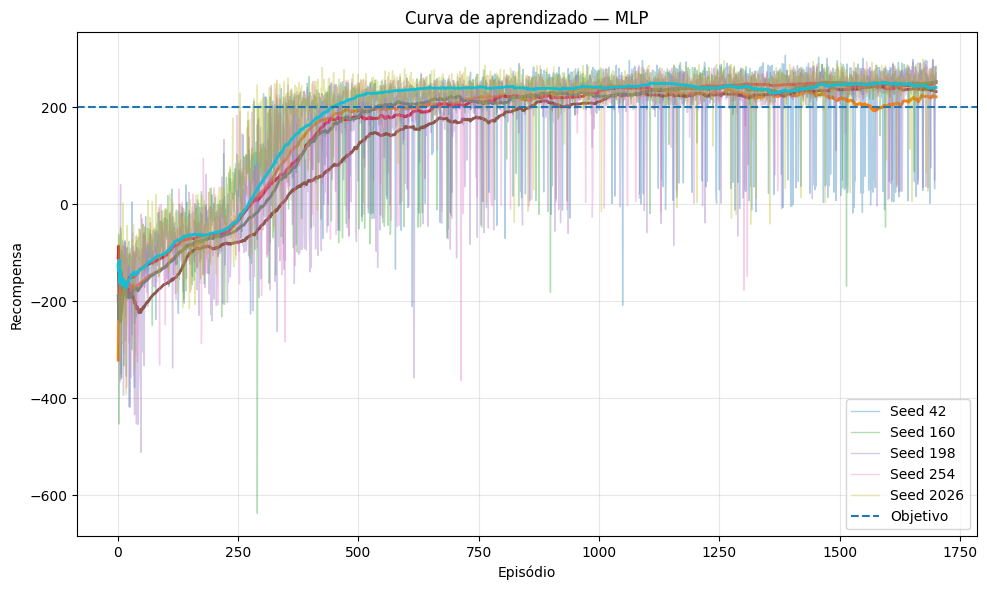

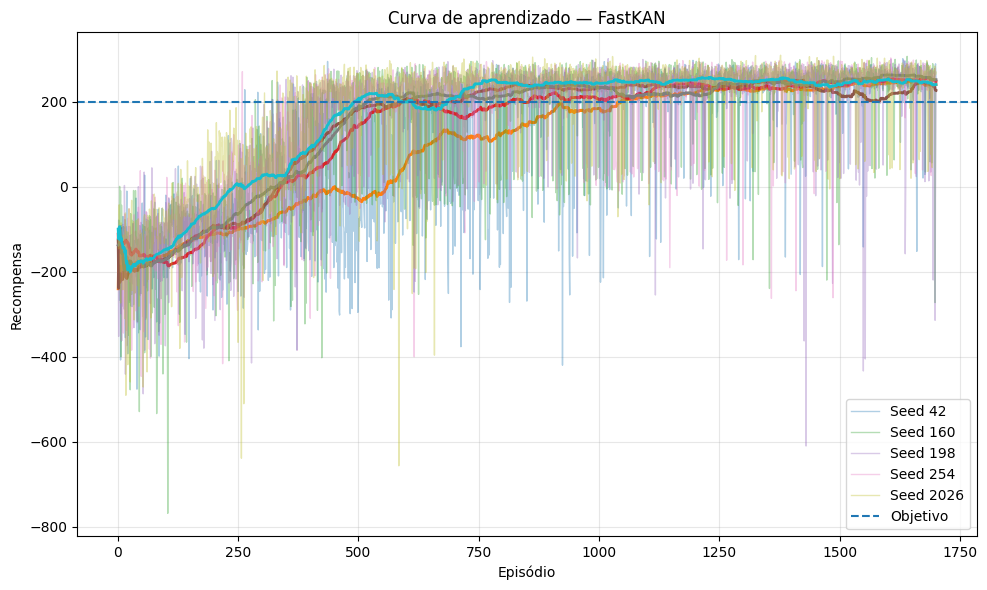

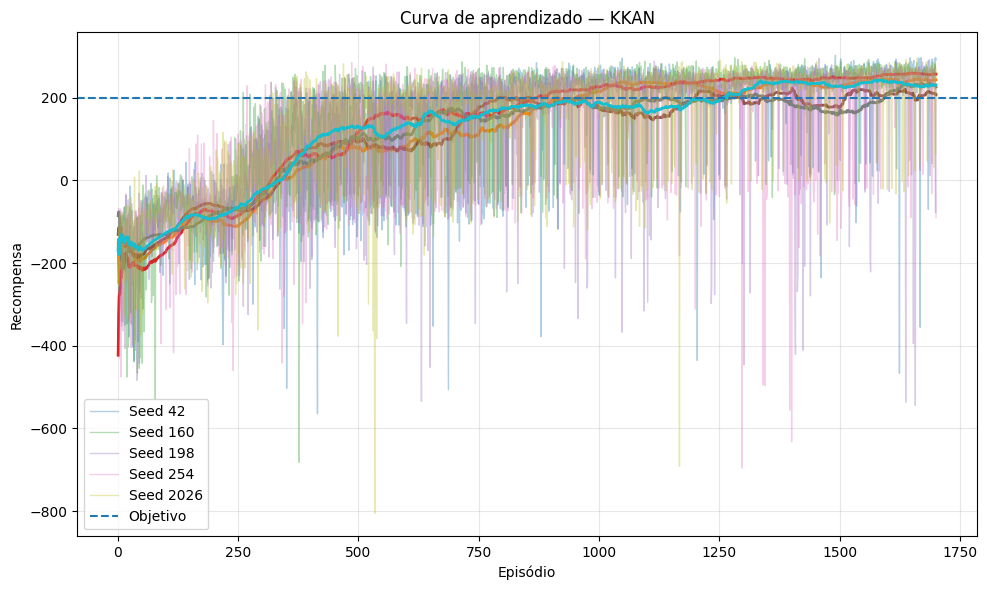

In [ ]:
# plotar as curvas
for modelo, df in dados.items():
  plot_curvas_seeds(
      df,
      modelo
  )

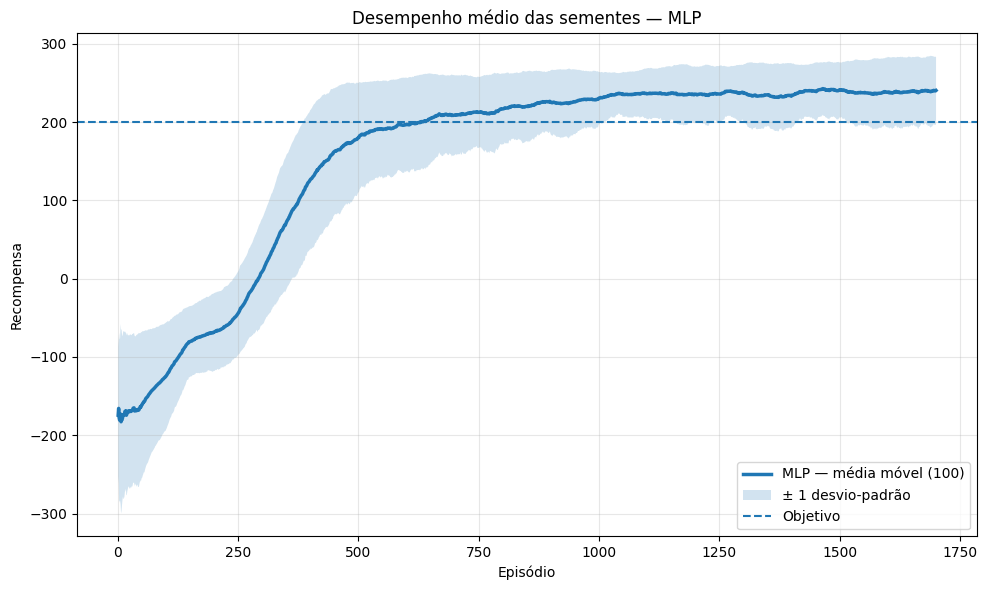

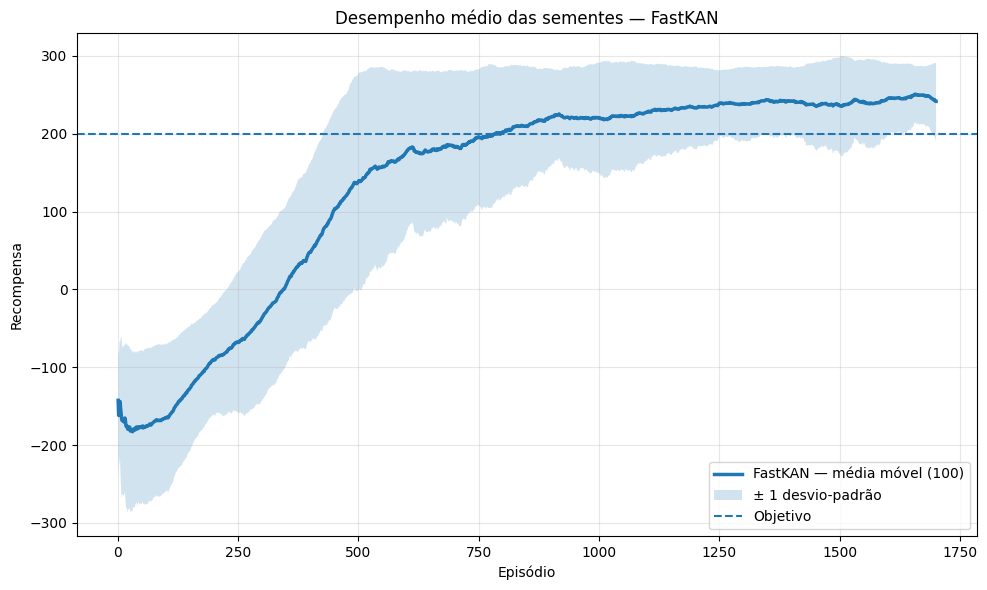

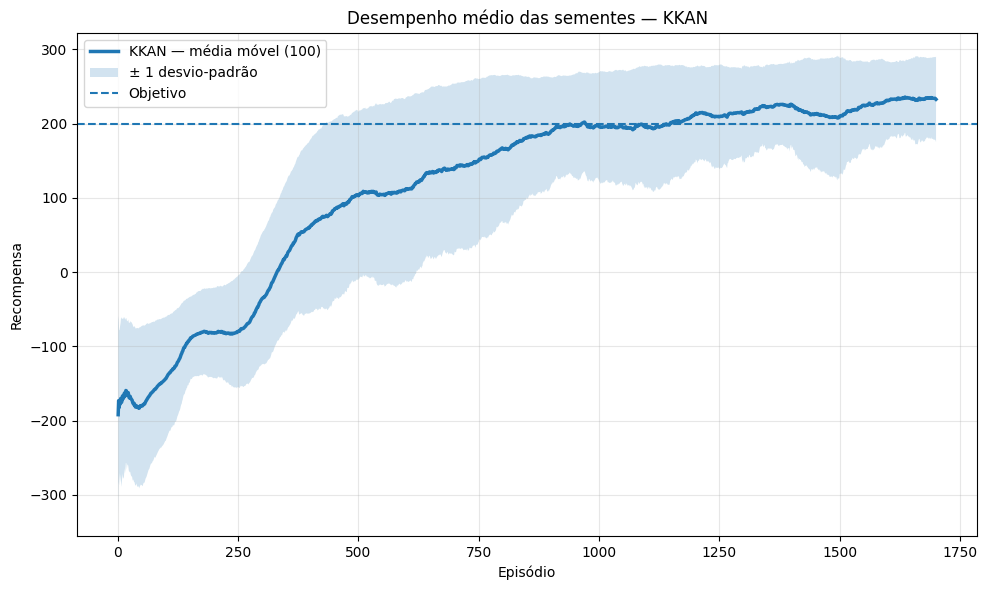

In [ ]:
# caluclo estatistica
for modelo, df in dados.items():
  estatisticas[modelo] = (
      calcular_estatisticas_por_episodio(df)
  )

# plota média e desvio padrão
for modelo, estat in estatisticas.items():
  plot_media_desvio(estat,modelo)

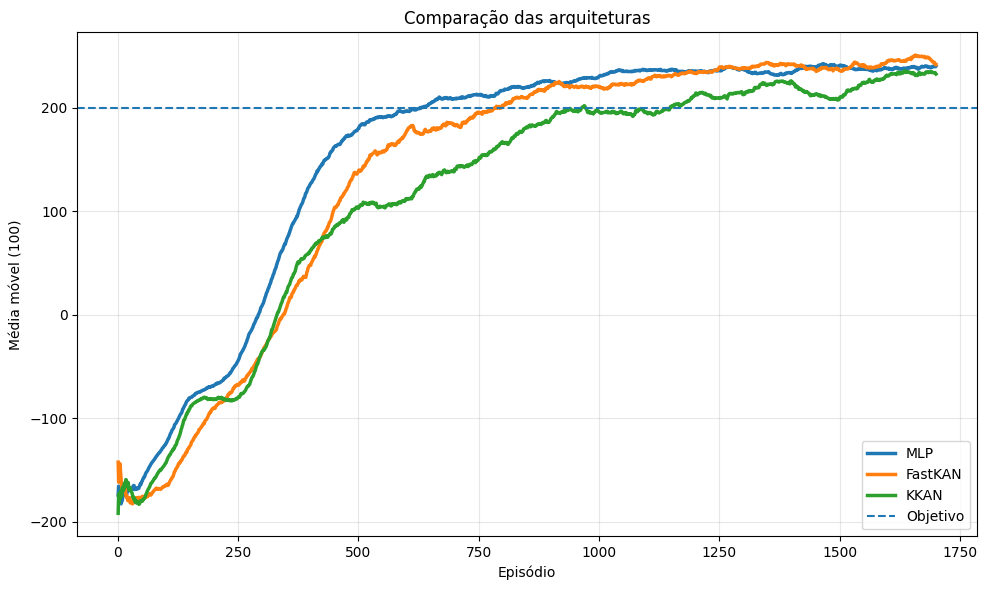

In [ ]:
# Plota comparação das redes
plot_comparacao(dados)

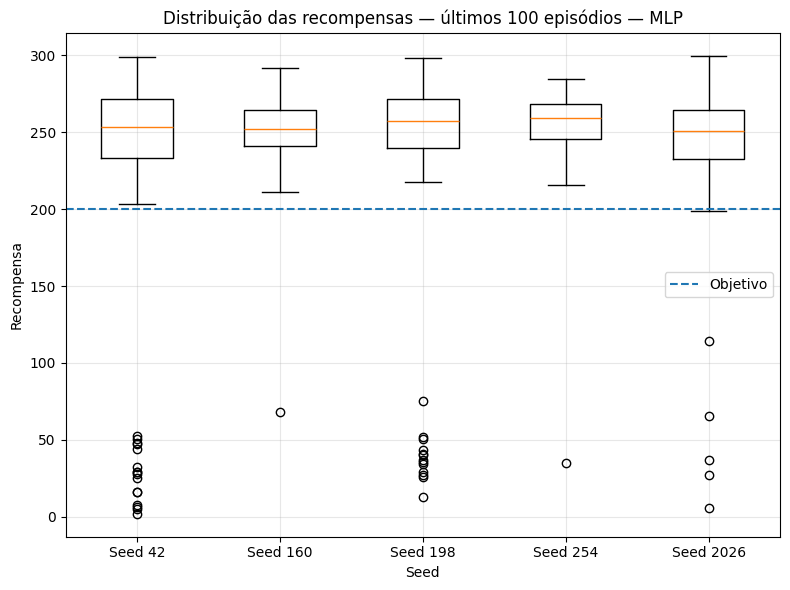

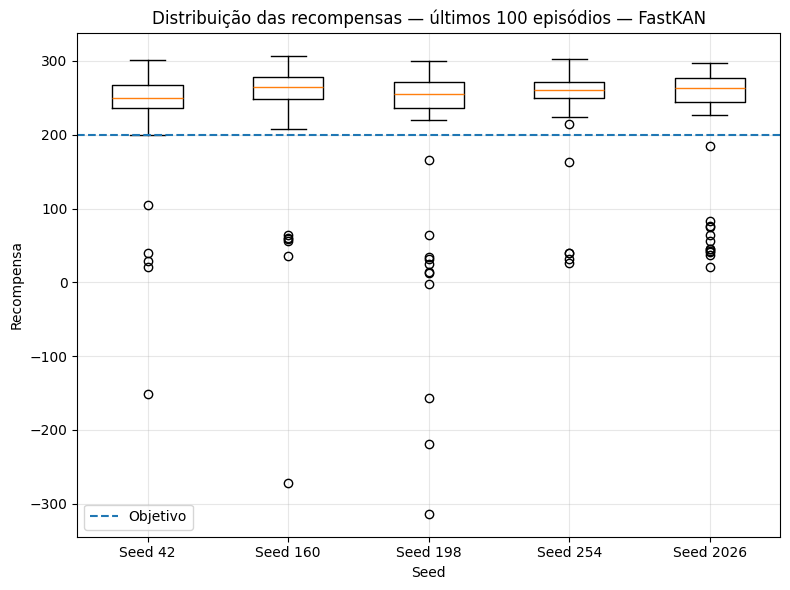

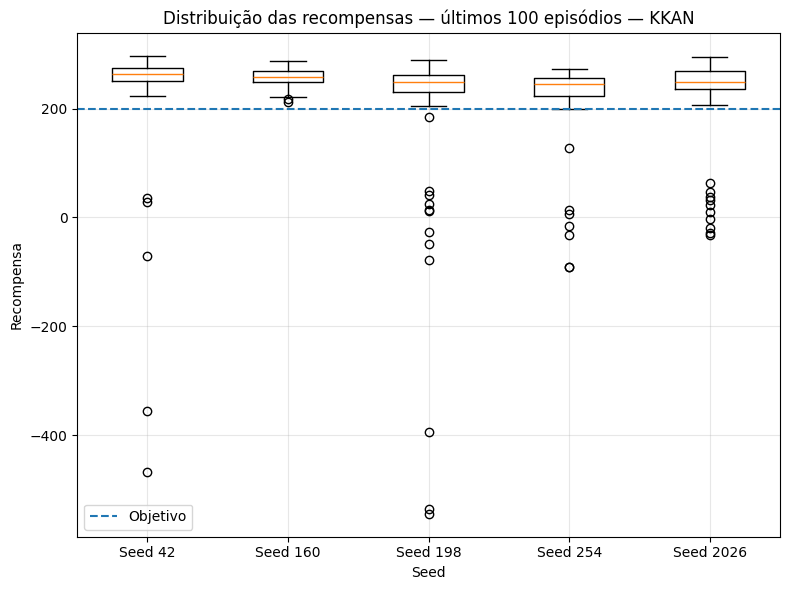

In [ ]:
# plota distribuicao final
for modelo, df in dados.items():
  plot_distribuicao_final(
      df,
      modelo
  )

In [ ]:
# calcular e plotar outras métricas
metricas = []
# resumos = []
for modelo, df in dados.items():
  print(f"\nCalculando métricas: {modelo}")
  df_metricas, resumo = calcular_metricas_finais(
      df,
      modelo
  )
  metricas.append(df_metricas)
  resumos.append(resumo)

# Junta os resultados das 3 arquiteturas = resumo estatístico entre as 5 seeds
metricas = pd.concat(
    metricas,
    ignore_index=True
)

resumo = (
    metricas
    .groupby("modelo")
    .agg(
        media_100=("media_100", "mean"),
        desvio_100=("media_100", "std"),
        melhor_reward=("melhor_reward", "mean"),
        taxa_sucesso=("taxa_sucesso", "mean")
    )
    .reset_index()
)

tempos = []
for modelo, arquivo in ARQUIVOS_TEMPO.items():
  caminho = PASTA_RECOMPENSA / arquivo
  df_tempo = pd.read_csv(caminho)
  df_tempo["modelo"] = modelo
  tempos.append(df_tempo)

tempos = pd.concat(
    tempos,
    ignore_index=True
)

tempo_resumo = (
    tempos
    .groupby("modelo")["tempo_segundos"]
    .agg(
        tempo_medio="mean",
        tempo_std="std",
        tempo_min="min",
        tempo_max="max"
    )
    .reset_index()
)

resumo_final = resumo.merge(
    tempo_resumo,
    on="modelo",
    how="left"
)

print("Métricas por seed:")
print(
    metricas.to_string(
        index=False
    )
)
print("Resumo das arquiteturas:")
print(
    resumo_final.to_string(
        index=False
    )
)


Calculando métricas: MLP

Calculando métricas: FastKAN

Calculando métricas: KKAN
Métricas por seed:
 modelo  seed  media_100  desvio_100  melhor_reward  taxa_sucesso
    MLP    42   222.0292   87.774727         307.72          84.0
    MLP   160   251.4828   24.335918         292.74          99.0
    MLP   198   232.6644   77.475495         298.45          87.0
    MLP   254   254.3856   27.346560         294.23          99.0
    MLP  2026   241.2727   49.630967         299.80          94.0
FastKAN    42   240.7480   60.567030         301.51          94.0
FastKAN   160   248.1922   72.367540         307.12          94.0
FastKAN   198   226.7834  103.169359         301.59          89.0
FastKAN   254   252.1106   48.848771         303.36          95.0
FastKAN  2026   240.7675   69.036455         309.73          88.0
   KKAN    42   243.0208  106.500901         302.57          95.0
   KKAN   160   257.1189   16.258663         296.27         100.0
   KKAN   198   207.0088  143.546777    

##Salvar

In [ ]:
# Salvar as tabelas
metricas.to_csv(
    PASTA_SAIDA / "metricas_por_seed.csv",
    index=False
)

resumo_final.to_csv(
    PASTA_SAIDA / "resumo_modelos.csv",
    index=False
)
tempos.to_csv(
    PASTA_SAIDA / "tempos_por_seed.csv",
    index=False
)
print("\nArquivos gerados em:")
print(PASTA_SAIDA.resolve())


Arquivos gerados em:
/content/graficos
